# Lab Report 02 - Running Code

This notebook covers the full practical content from the `Lab Report 02` folder with separate runnable Python cells and explanatory comments.

In [1]:
# Optional install command for Jupyter or Colab.
# Run this only if OpenCV is missing in your environment.
# !pip install opencv-python mediapipe --quiet

In [2]:
# Import the libraries used in this practical.
# cv2        -> image reading, color conversion, histogram calculation
# numpy      -> statistical calculations and array operations
# matplotlib -> displaying images and plotting graphs
# pathlib    -> locating the image safely
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Configure default plotting style.
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["image.cmap"] = "gray"

In [3]:
# Search for Girl.jpg in likely locations.
# This lets the notebook work from the project root or the Lab Report 02 folder.
candidate_paths = [
    Path("Girl.jpg"),
    Path("../Girl.jpg"),
    Path(r"C:/Users/kavin/OneDrive/Documents/Projects/Digital Image Processing and Computer Vision/Girl.jpg"),
]

# Select the first path that exists.
image_path = next((path for path in candidate_paths if path.exists()), None)

# Stop with a clear error if the image file is missing.
if image_path is None:
    raise FileNotFoundError(
        "Could not find 'Girl.jpg'. Keep it in the project root or current working directory."
    )

# Read the image using OpenCV.
# OpenCV loads color images in BGR order.
image_bgr = cv2.imread(str(image_path))

if image_bgr is None:
    raise ValueError(f"OpenCV could not read the image: {image_path}")

print(f"Loaded image from: {image_path.resolve()}")
print(f"BGR image shape: {image_bgr.shape}")

Loaded image from: C:\Users\kavin\OneDrive\Documents\Projects\Digital Image Processing and Computer Vision\Girl.jpg
BGR image shape: (512, 512, 3)


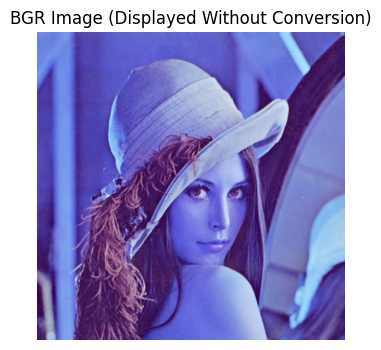

In [4]:
# Display the image directly in BGR form.
# The colors appear incorrect because matplotlib expects RGB order.
plt.figure(figsize=(12, 4))
plt.imshow(image_bgr)
plt.title("BGR Image (Displayed Without Conversion)")
plt.axis("off")
plt.show()

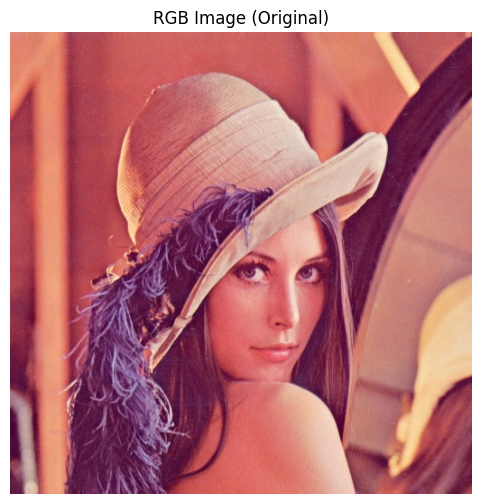

In [5]:
# Convert the image from BGR to RGB for correct display in matplotlib.
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Display the correctly converted RGB image.
plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.title("RGB Image (Original)")
plt.axis("off")
plt.show()

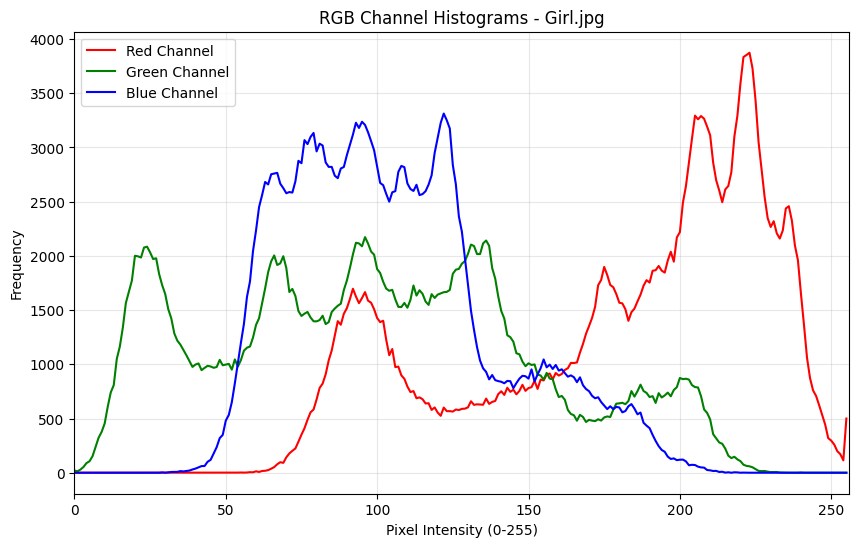

In [6]:
# Define plot colors and readable names for the RGB channels.
colors = ("r", "g", "b")
channel_names = ["Red", "Green", "Blue"]

# Plot RGB histograms directly from the RGB image.
# A histogram shows how pixel intensity values are distributed.
plt.figure(figsize=(10, 6))

for i, color in enumerate(colors):
    # Calculate the histogram for one channel with 256 bins.
    hist = cv2.calcHist([image_rgb], [i], None, [256], [0, 256])
    plt.plot(hist, color=color, label=f"{channel_names[i]} Channel")

plt.title("RGB Channel Histograms - Girl.jpg")
plt.xlabel("Pixel Intensity (0-255)")
plt.ylabel("Frequency")
plt.xlim([0, 256])
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [7]:
# Compute histogram-based mean and standard deviation for each channel.
# This uses histogram frequencies as weights.
print("=" * 60)
print("CHANNEL ANALYSIS USING HISTOGRAM WEIGHTS")
print("=" * 60)

for i, name in enumerate(channel_names):
    # Calculate and flatten the histogram for the current channel.
    hist = cv2.calcHist([image_rgb], [i], None, [256], [0, 256]).flatten()

    # Intensity values range from 0 to 255.
    intensity_values = np.arange(256)

    # Weighted average intensity of the channel.
    mean_intensity = np.average(intensity_values, weights=hist)

    # Weighted standard deviation of the channel.
    std_intensity = np.sqrt(
        np.average((intensity_values - mean_intensity) ** 2, weights=hist)
    )

    print(f"{name} Channel Analysis:")
    print(f"   Mean Intensity     : {mean_intensity:.2f}")
    print(f"   Standard Deviation : {std_intensity:.2f}")
    print()

CHANNEL ANALYSIS USING HISTOGRAM WEIGHTS
Red Channel Analysis:
   Mean Intensity     : 179.74
   Standard Deviation : 49.08

Green Channel Analysis:
   Mean Intensity     : 99.56
   Standard Deviation : 52.73

Blue Channel Analysis:
   Mean Intensity     : 105.38
   Standard Deviation : 33.89



In [8]:
# Split the RGB image into individual red, green, and blue channels.
# Each resulting channel is a 2D matrix of intensity values.
r_channel, g_channel, b_channel = cv2.split(image_rgb)

print("=" * 60)
print("IMAGE AND CHANNEL SHAPES")
print("=" * 60)
print(f"Original RGB Image Shape : {image_rgb.shape}")
print(f"Red Channel Shape        : {r_channel.shape}")
print(f"Green Channel Shape      : {g_channel.shape}")
print(f"Blue Channel Shape       : {b_channel.shape}")

IMAGE AND CHANNEL SHAPES
Original RGB Image Shape : (512, 512, 3)
Red Channel Shape        : (512, 512)
Green Channel Shape      : (512, 512)
Blue Channel Shape       : (512, 512)


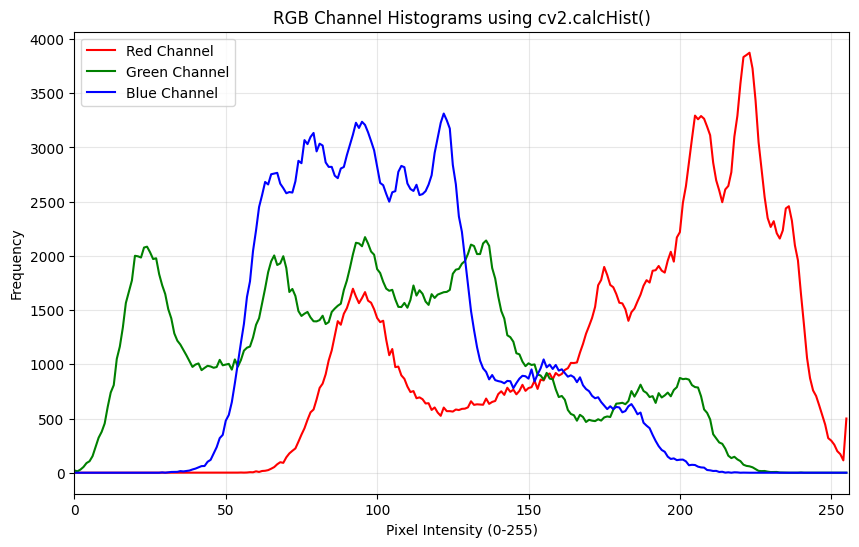

In [9]:
# Calculate histograms again using the separated channels.
# Since each variable is now a single-channel image, the channel index is 0.
hist_r = cv2.calcHist([r_channel], [0], None, [256], [0, 256])
hist_g = cv2.calcHist([g_channel], [0], None, [256], [0, 256])
hist_b = cv2.calcHist([b_channel], [0], None, [256], [0, 256])

# Plot the separated channel histograms together.
plt.figure(figsize=(10, 6))
plt.plot(hist_r, color="r", label="Red Channel")
plt.plot(hist_g, color="g", label="Green Channel")
plt.plot(hist_b, color="b", label="Blue Channel")
plt.title("RGB Channel Histograms using cv2.calcHist()")
plt.xlabel("Pixel Intensity (0-255)")
plt.ylabel("Frequency")
plt.xlim([0, 256])
plt.legend()
plt.grid(alpha=0.3)
plt.show()

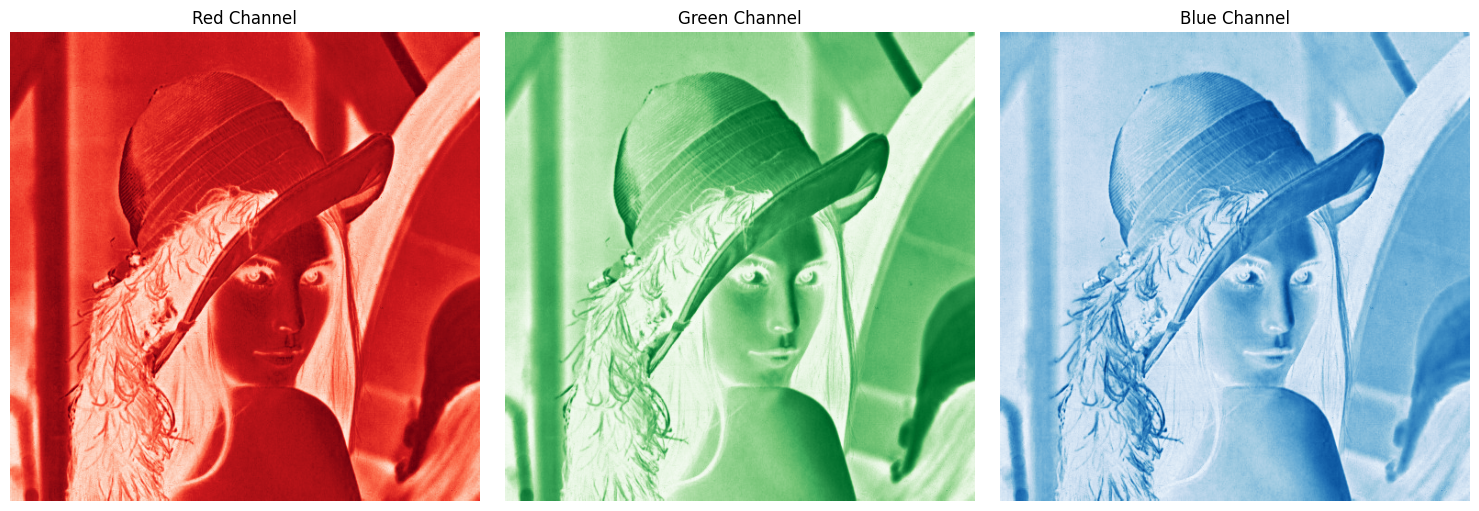

In [10]:
# Display the red, green, and blue channels separately.
# Bright regions mean higher intensity in that channel.
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(r_channel, cmap="Reds")
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(g_channel, cmap="Greens")
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(b_channel, cmap="Blues")
plt.title("Blue Channel")
plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
# Define a reusable function for channel statistics.
# The function calculates mean, standard deviation, and peak intensity.
def channel_stats(channel, name):
    # Mean intensity is the average brightness of the channel.
    mean = np.mean(channel)

    # Standard deviation measures intensity variation.
    std = np.std(channel)

    # Histogram is used to find the most frequent intensity value.
    hist = cv2.calcHist([channel], [0], None, [256], [0, 256])
    peak = int(np.argmax(hist))

    print(f"{name:5} Channel | Mean: {mean:6.2f} | Std: {std:6.2f} | Peak Intensity: {peak:3}")
    return mean, std, peak

In [12]:
# Run the statistics function for each RGB channel.
print("=" * 70)
print("RGB CHANNEL STATISTICS")
print("=" * 70)

r_stats = channel_stats(r_channel, "Red")
g_stats = channel_stats(g_channel, "Green")
b_stats = channel_stats(b_channel, "Blue")

print("=" * 70)

RGB CHANNEL STATISTICS
Red   Channel | Mean: 179.74 | Std:  49.08 | Peak Intensity: 223
Green Channel | Mean:  99.56 | Std:  52.73 | Peak Intensity:  96
Blue  Channel | Mean: 105.38 | Std:  33.89 | Peak Intensity: 122


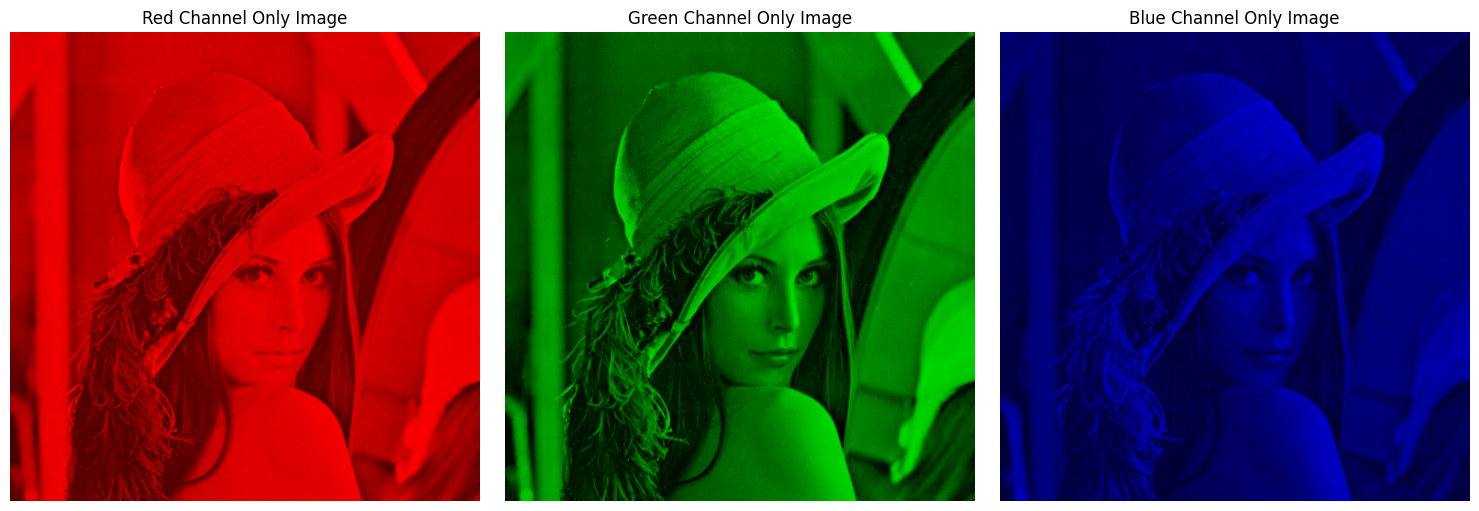

In [13]:
# Create color-only visualizations.
# Each output image keeps only one color component and sets the others to zero.
red_only = np.zeros_like(image_rgb)
green_only = np.zeros_like(image_rgb)
blue_only = np.zeros_like(image_rgb)

# In RGB format: index 0=Red, 1=Green, 2=Blue.
red_only[:, :, 0] = r_channel
green_only[:, :, 1] = g_channel
blue_only[:, :, 2] = b_channel

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(red_only)
plt.title("Red Channel Only Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(green_only)
plt.title("Green Channel Only Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(blue_only)
plt.title("Blue Channel Only Image")
plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
# Final summary of the practical steps completed.
print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)
print("1. The image was loaded using OpenCV.")
print("2. OpenCV reads color images in BGR format.")
print("3. The image was converted to RGB for correct display in Matplotlib.")
print("4. RGB histograms were calculated to analyze intensity distribution.")
print("5. The image was split into Red, Green, and Blue channels.")
print("6. Each channel was displayed separately.")
print("7. Mean, standard deviation, and peak intensity were calculated.")
print("8. Color-only visualization images were created for each channel.")
print("=" * 70)


FINAL SUMMARY
1. The image was loaded using OpenCV.
2. OpenCV reads color images in BGR format.
3. The image was converted to RGB for correct display in Matplotlib.
4. RGB histograms were calculated to analyze intensity distribution.
5. The image was split into Red, Green, and Blue channels.
6. Each channel was displayed separately.
7. Mean, standard deviation, and peak intensity were calculated.
8. Color-only visualization images were created for each channel.
